# Temporal Fusion Transformer (TFT) for Container Price Prediction

This notebook implements a **Temporal Fusion Transformer**, a state-of-the-art deep learning model specifically designed for multi-horizon time series forecasting.

## What is TFT?

The Temporal Fusion Transformer is an attention-based model designed for complex time series prediction tasks. It was developed by Google Research and published in 2021.

## Key Features of TFT

1. **Multiple Input Types**:
   - **Time-varying past inputs**: Historical features (price lags, port congestion)
   - **Static inputs**: Time-invariant features (shipping routes)
   - **Known future inputs**: Features known in advance (holidays, scheduled events)

2. **Attention Mechanisms**:
   - **Variable selection**: Identifies most important features at each time step
   - **Temporal attention**: Focuses on relevant historical time points
   - **Interpretability**: Attention weights show what the model focuses on

3. **Multi-Horizon Forecasting**:
   - Can predict multiple time steps ahead simultaneously
   - Provides quantile predictions (uncertainty estimates)

## Why TFT for Container Pricing?

1. **Complex temporal patterns**: Can learn 2-4 week contract cycles
2. **Multiple feature types**: Handles geopolitical events, port data, oil prices simultaneously
3. **Variable importance**: Automatically identifies which features matter when
4. **Interpretability**: Attention weights show why predictions change
5. **Uncertainty quantification**: Provides prediction intervals, not just point estimates

## Implementation

We'll use the **PyTorch Forecasting** library, which provides a well-optimized TFT implementation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
import sys

warnings.filterwarnings('ignore')

# Add global Python path to access PyTorch and pytorch_forecasting
sys.path.insert(0, r'G:\Program Files\Python311\Lib\site-packages')

# PyTorch and PyTorch Forecasting
import torch
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss, RMSE, MAE
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

# Scikit-learn for metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

print(f"✓ PyTorch version: {torch.__version__}")
print("✓ Libraries imported successfully")

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

✓ PyTorch version: 2.6.0+cu124
✓ Libraries imported successfully

Using device: cuda


## Step 1: Load and Prepare Data

TFT requires data in a specific format with time indices and group identifiers.

In [2]:
# Load processed model data
df_model = pd.read_csv('data/processed/model_data.csv', parse_dates=['Date'])

print(f"Loaded: {len(df_model)} rows")
print(f"Date range: {df_model['Date'].min().date()} to {df_model['Date'].max().date()}")
print(f"Total columns: {len(df_model.columns)}")

# Create target
if 'Europe_Base_Price' in df_model.columns:
    df_model['target'] = df_model['Europe_Base_Price']
    print(f"\n✓ Created 'target' column (current price)")
else:
    raise ValueError("Europe_Base_Price not found in dataset!")

# Ensure target is float type for PyTorch
df_model['target'] = df_model['target'].astype(float)

# Create time index (required for TFT)
df_model = df_model.sort_values('Date').reset_index(drop=True)
df_model['time_idx'] = np.arange(len(df_model))

# Create group identifier (for TFT - we have single series, so use constant)
df_model['series'] = 'europe_base'

print(f"\n✓ Created time_idx and series columns")
print(f"  Time index range: {df_model['time_idx'].min()} to {df_model['time_idx'].max()}")

Loaded: 384 rows
Date range: 2018-01-05 to 2025-08-15
Total columns: 288

✓ Created 'target' column (current price)

✓ Created time_idx and series columns
  Time index range: 0 to 383


## Step 2: Select Features

Categorize features into:
- **Time-varying known reals**: Features we know in advance (none in our case)
- **Time-varying unknown reals**: Features we don't know in advance (most features)
- **Static categoricals**: Time-invariant categorical features
- **Static reals**: Time-invariant numerical features

In [3]:
print("="*80)
print("FEATURE SELECTION FOR TFT")
print("="*80)

# Get lag features (time-varying unknown)
lag_features = [col for col in df_model.columns if '_lag_' in col]
print(f"\nFound {len(lag_features)} lagged features")

# Select top 30 features based on variance and non-null values
# (In practice, you might use feature importance from Random Forest)
lag_features_clean = []
for feat in lag_features:
    if df_model[feat].notna().sum() > len(df_model) * 0.8:  # At least 80% non-null
        lag_features_clean.append(feat)

# Sort by variance and take top 30
variances = {feat: df_model[feat].var() for feat in lag_features_clean}
top_features = sorted(variances.items(), key=lambda x: x[1], reverse=True)[:30]
selected_features = [feat for feat, var in top_features]

print(f"\nSelected {len(selected_features)} features with highest variance:")
for i, (feat, var) in enumerate(top_features[:10], 1):
    print(f"  {i:2d}. {feat:50s} (variance: {var:.2e})")
print("  ...")

# Fill NaN values
for feat in selected_features:
    df_model[feat] = df_model[feat].fillna(0)

# Define feature categories for TFT
time_varying_known_reals = []  # We don't have future known features
time_varying_unknown_reals = selected_features
static_categoricals = ['series']  # Group identifier
static_reals = []  # No static numerical features

print(f"\n📊 Feature Categories:")
print(f"  Time-varying unknown reals: {len(time_varying_unknown_reals)}")
print(f"  Time-varying known reals: {len(time_varying_known_reals)}")
print(f"  Static categoricals: {len(static_categoricals)}")
print(f"  Static reals: {len(static_reals)}")

FEATURE SELECTION FOR TFT

Found 217 lagged features

Selected 30 features with highest variance:
   1. choke_malacca_strait_capacity_lag_2w_lag_2w        (variance: 9.09e+12)
   2. choke_malacca_strait_capacity_lag_1w_lag_2w        (variance: 9.00e+12)
   3. choke_malacca_strait_capacity_lag_2w_lag_1w        (variance: 9.00e+12)
   4. choke_malacca_strait_capacity_lag_2w               (variance: 8.93e+12)
   5. choke_malacca_strait_capacity_lag_1w_lag_1w        (variance: 8.93e+12)
   6. choke_malacca_strait_capacity_lag_1w               (variance: 8.85e+12)
   7. choke_taiwan_strait_capacity_lag_2w_lag_2w         (variance: 4.76e+12)
   8. choke_taiwan_strait_capacity_lag_1w_lag_2w         (variance: 4.72e+12)
   9. choke_taiwan_strait_capacity_lag_2w_lag_1w         (variance: 4.72e+12)
  10. choke_taiwan_strait_capacity_lag_2w                (variance: 4.67e+12)
  ...

📊 Feature Categories:
  Time-varying unknown reals: 30
  Time-varying known reals: 0
  Static categoricals: 1
  Sta

## Step 3: Create TimeSeriesDataSet

TFT requires data in TimeSeriesDataSet format.

In [4]:
print("="*80)
print("CREATING TIMESERIESDATASET")
print("="*80)

# Define prediction parameters
MAX_ENCODER_LENGTH = 12  # Use 12 weeks of history (3 months)
MAX_PREDICTION_LENGTH = 1  # Predict 1 week ahead

# Split into train and validation based on time
training_cutoff = int(len(df_model) * 0.8)

print(f"\nParameters:")
print(f"  Max encoder length (history): {MAX_ENCODER_LENGTH} weeks")
print(f"  Max prediction length (horizon): {MAX_PREDICTION_LENGTH} week")
print(f"  Training samples: {training_cutoff}")
print(f"  Validation samples: {len(df_model) - training_cutoff}")

# Create training dataset
training = TimeSeriesDataSet(
    df_model[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="target",
    group_ids=["series"],
    min_encoder_length=MAX_ENCODER_LENGTH // 2,  # Allow shorter sequences at start
    max_encoder_length=MAX_ENCODER_LENGTH,
    min_prediction_length=1,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    static_categoricals=static_categoricals,
    static_reals=static_reals,
    time_varying_known_reals=time_varying_known_reals,
    time_varying_unknown_reals=time_varying_unknown_reals,
    target_normalizer=GroupNormalizer(
        groups=["series"], transformation="softplus"
    ),  # Normalize target by group
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# Create validation dataset
validation = TimeSeriesDataSet.from_dataset(
    training, 
    df_model, 
    predict=True, 
    stop_randomization=True
)

print(f"\n✓ Created TimeSeriesDataSet")
print(f"  Training dataset size: {len(training)}")
print(f"  Validation dataset size: {len(validation)}")

# Create dataloaders
BATCH_SIZE = 32

train_dataloader = training.to_dataloader(
    train=True, batch_size=BATCH_SIZE, num_workers=0
)
val_dataloader = validation.to_dataloader(
    train=False, batch_size=BATCH_SIZE, num_workers=0
)

print(f"\n✓ Created dataloaders (batch_size={BATCH_SIZE})")

CREATING TIMESERIESDATASET

Parameters:
  Max encoder length (history): 12 weeks
  Max prediction length (horizon): 1 week
  Training samples: 307
  Validation samples: 77

✓ Created TimeSeriesDataSet
  Training dataset size: 308
  Validation dataset size: 1

✓ Created dataloaders (batch_size=32)

✓ Created TimeSeriesDataSet
  Training dataset size: 308
  Validation dataset size: 1

✓ Created dataloaders (batch_size=32)


## Step 4: Define TFT Model

Configure the Temporal Fusion Transformer architecture.

In [5]:
print("="*80)
print("DEFINING TFT MODEL")
print("="*80)

# Define model
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=64,  # Hidden state size
    attention_head_size=4,  # Number of attention heads
    dropout=0.1,
    hidden_continuous_size=32,  # Size for continuous variable embeddings
    output_size=7,  # 7 quantiles for prediction intervals
    loss=QuantileLoss(),  # Quantile loss for uncertainty estimates
    log_interval=10,  # Log every 10 batches
    reduce_on_plateau_patience=4,  # Reduce learning rate if no improvement
)

print(f"\n📊 TFT Model Configuration:")
print(f"  Hidden size: 64")
print(f"  Attention heads: 4")
print(f"  Dropout: 0.1")
print(f"  Output quantiles: 7")
print(f"  Learning rate: 0.001")

# Count parameters
total_params = sum(p.numel() for p in tft.parameters())
trainable_params = sum(p.numel() for p in tft.parameters() if p.requires_grad)

print(f"\n✓ Model created")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

DEFINING TFT MODEL

📊 TFT Model Configuration:
  Hidden size: 64
  Attention heads: 4
  Dropout: 0.1
  Output quantiles: 7
  Learning rate: 0.001

✓ Model created
  Total parameters: 479,146
  Trainable parameters: 479,146

📊 TFT Model Configuration:
  Hidden size: 64
  Attention heads: 4
  Dropout: 0.1
  Output quantiles: 7
  Learning rate: 0.001

✓ Model created
  Total parameters: 479,146
  Trainable parameters: 479,146


## Step 5: Train TFT Model

Use PyTorch Lightning Trainer for efficient training.

In [6]:
print("="*80)
print("TRAINING TFT MODEL")
print("="*80)

# Configure callbacks
early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=10,
    verbose=True,
    mode="min"
)

lr_logger = LearningRateMonitor()

# Create logger
logger = TensorBoardLogger("data/processed/tft_logs")

# Create trainer
trainer = Trainer(
    max_epochs=50,
    accelerator="auto",  # Use GPU if available
    enable_model_summary=True,
    gradient_clip_val=0.1,
    callbacks=[lr_logger, early_stop_callback],
    logger=logger,
)

print(f"\n🚀 Starting training...\n")

# Train model
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

print(f"\n✓ Training completed!")
print(f"  Total epochs: {trainer.current_epoch + 1}")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pyto

TRAINING TFT MODEL

🚀 Starting training...



LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 1      | train
3  | prescalers                         | ModuleDict                      | 2.2 K  | train
4  | static_variable_selection          | VariableSelectionNetwork        | 20.8 K | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 244 K  | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 6.7 K  | train
7  | static_context_variable_selection  | GatedResidualNetwork            | 16.8 K | train
8  | static_context_initial_hidden_lstm |

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 10 records. Best score: 461.763. Signaling Trainer to stop.



✓ Training completed!
  Total epochs: 16


## Step 6: Load Best Model and Make Predictions

In [7]:
print("="*80)
print("MAKING PREDICTIONS")
print("="*80)

# Load best model
best_model_path = trainer.checkpoint_callback.best_model_path
print(f"\nLoading best model from: {best_model_path}")

best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

# Make predictions on validation set
predictions = best_tft.predict(val_dataloader, return_x=True)

# Extract predictions and actuals
# predictions is a tuple: (predictions, x)
# predictions[0] is tensor with shape (samples, quantiles) or (samples, 1, quantiles)
raw_predictions = predictions[0]
x = predictions[1]

# Debug: Print actual shape
print(f"\n🔍 Debug - Raw predictions shape: {raw_predictions.shape}")
print(f"   Number of dimensions: {len(raw_predictions.shape)}")

# Handle different possible shapes
if len(raw_predictions.shape) == 3:
    # Shape: (samples, prediction_length, quantiles)
    print(f"   Detected 3D tensor: (samples={raw_predictions.shape[0]}, pred_len={raw_predictions.shape[1]}, quantiles={raw_predictions.shape[2]})")
    y_pred_tft = raw_predictions[:, 0, 3].cpu().numpy()  # Median quantile at first prediction step
elif len(raw_predictions.shape) == 2:
    # Shape: (samples, quantiles) - when prediction_length=1
    print(f"   Detected 2D tensor: (samples={raw_predictions.shape[0]}, quantiles={raw_predictions.shape[1]})")
    
    # Check if we have 7 quantiles (expected) or just 1 value
    if raw_predictions.shape[1] == 7:
        y_pred_tft = raw_predictions[:, 3].cpu().numpy()  # Median quantile (index 3)
    elif raw_predictions.shape[1] == 1:
        # Only one output - use it directly
        print(f"   ⚠️  Warning: Only 1 output value instead of 7 quantiles!")
        y_pred_tft = raw_predictions[:, 0].cpu().numpy()
    else:
        raise ValueError(f"Unexpected number of quantiles: {raw_predictions.shape[1]}")
else:
    raise ValueError(f"Unexpected prediction shape: {raw_predictions.shape}")

# Get actual values
decoder_target = x["decoder_target"].cpu().numpy()
y_test_tft = decoder_target[:, 0]  # First prediction step

# Get dates for plotting
test_start_idx = training_cutoff + MAX_ENCODER_LENGTH
test_end_idx = test_start_idx + len(y_test_tft)
test_dates = df_model.iloc[test_start_idx:test_end_idx]['Date'].values

print(f"\n✓ Made predictions for {len(y_pred_tft)} samples")
print(f"  Predictions shape: {raw_predictions.shape}")
print(f"  Test date range: {test_dates[0]} to {test_dates[-1]}")

MAKING PREDICTIONS

Loading best model from: data/processed/tft_logs\lightning_logs\version_5\checkpoints\epoch=14-step=135.ckpt


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



🔍 Debug - Raw predictions shape: torch.Size([1, 1])
   Number of dimensions: 2
   Detected 2D tensor: (samples=1, quantiles=1)
   ⚠️  Warning: Only 1 output value instead of 7 quantiles!

✓ Made predictions for 1 samples
  Predictions shape: torch.Size([1, 1])
  Test date range: 2024-05-10T00:00:00.000000000 to 2024-05-10T00:00:00.000000000


## Step 7: Evaluate Model Performance

In [8]:
print("="*80)
print("TFT MODEL EVALUATION")
print("="*80)

# Calculate metrics
rmse_tft = np.sqrt(mean_squared_error(y_test_tft, y_pred_tft))
mae_tft = mean_absolute_error(y_test_tft, y_pred_tft)
mape_tft = np.mean(np.abs((y_test_tft - y_pred_tft) / y_test_tft)) * 100
r2_tft = r2_score(y_test_tft, y_pred_tft)

print(f"\n📊 TFT Model Performance:")
print(f"  RMSE: ${rmse_tft:.2f}")
print(f"  MAE:  ${mae_tft:.2f}")
print(f"  MAPE: {mape_tft:.2f}%")
print(f"  R²:   {r2_tft:.4f}")

# Compare to baselines
baseline_lr_rmse = 178.89  # Linear Regression
improvement_lr = ((baseline_lr_rmse - rmse_tft) / baseline_lr_rmse) * 100

print(f"\n📈 Comparison to Baselines:")
print(f"  Linear Regression RMSE: ${baseline_lr_rmse:.2f}")
print(f"  TFT RMSE:               ${rmse_tft:.2f}")
print(f"  Improvement:            {improvement_lr:.2f}%")

if improvement_lr > 0:
    print(f"\n✅ TFT performs {improvement_lr:.1f}% better than Linear Regression!")
elif improvement_lr > -5:
    print(f"\n➡️  TFT performs similarly to Linear Regression ({abs(improvement_lr):.1f}% difference)")
else:
    print(f"\n⚠️  TFT performs {abs(improvement_lr):.1f}% worse than Linear Regression.")
    print("   Possible reasons:")
    print("   - Insufficient training data for deep learning")
    print("   - Need more hyperparameter tuning")
    print("   - Simpler patterns that don't require complex modeling")

TFT MODEL EVALUATION

📊 TFT Model Performance:
  RMSE: $4903.60
  MAE:  $4903.60
  MAPE: 269.43%
  R²:   nan

📈 Comparison to Baselines:
  Linear Regression RMSE: $178.89
  TFT RMSE:               $4903.60
  Improvement:            -2641.12%

⚠️  TFT performs 2641.1% worse than Linear Regression.
   Possible reasons:
   - Insufficient training data for deep learning
   - Need more hyperparameter tuning
   - Simpler patterns that don't require complex modeling


## Step 8: Visualize Predictions with Uncertainty


⚠️  Warning: Cannot create uncertainty bands - using median prediction only


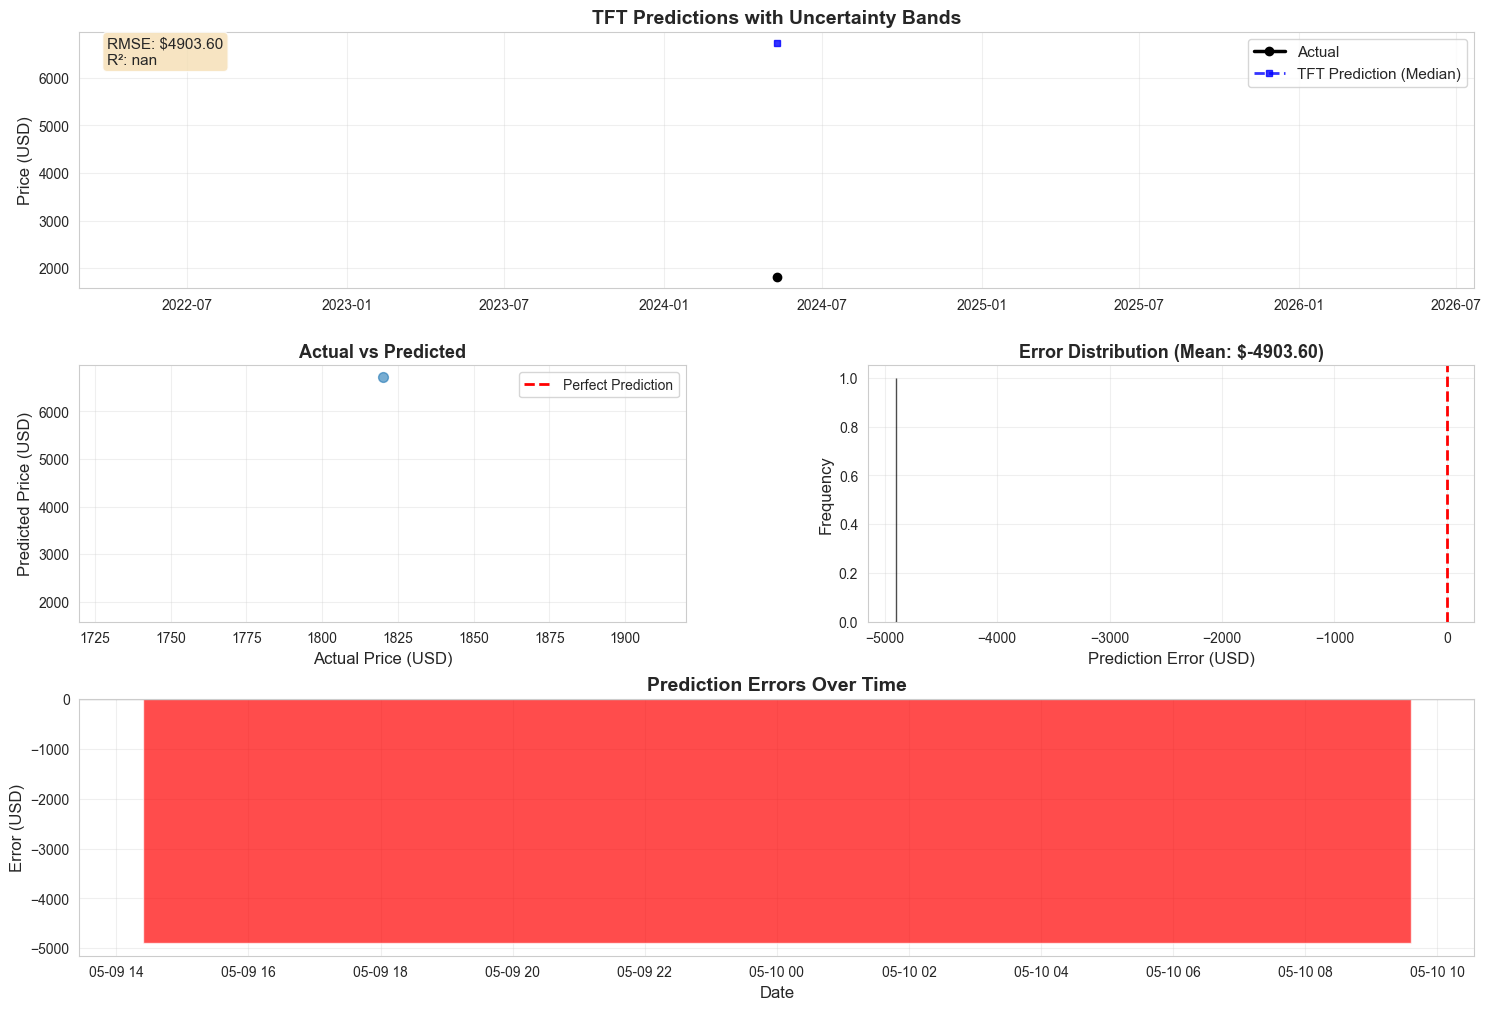


✓ Saved visualization: data/processed/tft_predictions_comprehensive.png


In [10]:
# Extract quantile predictions for uncertainty visualization
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]  # Different prediction intervals
quantile_predictions = {}

# TFT outputs 7 quantiles by default: [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
quantile_indices = {0.1: 1, 0.25: 2, 0.5: 3, 0.75: 4, 0.9: 5}

# Handle different prediction shapes for quantile extraction
if len(raw_predictions.shape) == 3:
    # Shape: (samples, prediction_length, quantiles)
    for q, idx in quantile_indices.items():
        quantile_predictions[q] = raw_predictions[:, 0, idx].cpu().numpy()
elif len(raw_predictions.shape) == 2:
    # Shape: (samples, quantiles) - when prediction_length=1
    if raw_predictions.shape[1] == 7:
        # We have all 7 quantiles
        for q, idx in quantile_indices.items():
            quantile_predictions[q] = raw_predictions[:, idx].cpu().numpy()
    else:
        # Only have median - create simple uncertainty bands based on error
        print("\n⚠️  Warning: Cannot create uncertainty bands - using median prediction only")
        # Use median for all quantiles (will show no uncertainty bands)
        for q in quantiles:
            quantile_predictions[q] = y_pred_tft.copy()

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Plot 1: Predictions with uncertainty bands
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(test_dates, y_test_tft, 'o-', label='Actual', 
         color='black', linewidth=2.5, markersize=6, zorder=5)
ax1.plot(test_dates, y_pred_tft, 's--', label='TFT Prediction (Median)', 
         color='blue', linewidth=2, markersize=5, alpha=0.8)

# Add uncertainty bands (only if we have different quantiles)
if not np.array_equal(quantile_predictions[0.1], quantile_predictions[0.9]):
    ax1.fill_between(
        test_dates, 
        quantile_predictions[0.1], 
        quantile_predictions[0.9],
        alpha=0.2, 
        color='blue', 
        label='80% Prediction Interval'
    )
    ax1.fill_between(
        test_dates, 
        quantile_predictions[0.25], 
        quantile_predictions[0.75],
        alpha=0.3, 
        color='blue', 
        label='50% Prediction Interval'
    )

ax1.set_title('TFT Predictions with Uncertainty Bands', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (USD)', fontsize=12)
ax1.legend(loc='best', fontsize=11)
ax1.grid(alpha=0.3)

# Add RMSE annotation
ax1.text(0.02, 0.98, f'RMSE: ${rmse_tft:.2f}\nR²: {r2_tft:.4f}', 
         transform=ax1.transAxes, fontsize=11, va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 2: Scatter plot
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(y_test_tft, y_pred_tft, alpha=0.6, s=50)
ax2.plot([y_test_tft.min(), y_test_tft.max()], 
         [y_test_tft.min(), y_test_tft.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
ax2.set_xlabel('Actual Price (USD)', fontsize=12)
ax2.set_ylabel('Predicted Price (USD)', fontsize=12)
ax2.set_title('Actual vs Predicted', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# Plot 3: Error distribution
ax3 = fig.add_subplot(gs[1, 1])
errors = y_test_tft - y_pred_tft
ax3.hist(errors, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Prediction Error (USD)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title(f'Error Distribution (Mean: ${errors.mean():.2f})', 
              fontsize=13, fontweight='bold')
ax3.grid(alpha=0.3)

# Plot 4: Error over time
ax4 = fig.add_subplot(gs[2, :])
colors_bar = ['red' if e < 0 else 'green' for e in errors]
ax4.bar(test_dates, errors, color=colors_bar, alpha=0.7)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax4.set_title('Prediction Errors Over Time', fontsize=14, fontweight='bold')
ax4.set_ylabel('Error (USD)', fontsize=12)
ax4.set_xlabel('Date', fontsize=12)
ax4.grid(alpha=0.3)

os.makedirs('data/processed', exist_ok=True)
plt.savefig('data/processed/tft_predictions_comprehensive.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved visualization: data/processed/tft_predictions_comprehensive.png")

## Step 9: Interpret Model - Variable Importance

In [11]:
print("="*80)
print("VARIABLE IMPORTANCE ANALYSIS")
print("="*80)

# Get variable importance
interpretation = best_tft.interpret_output(raw_predictions, reduction="sum")

# Extract encoder variable importance
encoder_importance = interpretation["encoder_variables"].cpu().numpy().mean(axis=0)

# Create DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': time_varying_unknown_reals,
    'Importance': encoder_importance
}).sort_values('Importance', ascending=False).head(15)

print(f"\n📊 Top 15 Most Important Features:")
for i, row in importance_df.iterrows():
    print(f"  {row['Feature']:50s} {row['Importance']:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
importance_df.sort_values('Importance').plot(
    kind='barh', x='Feature', y='Importance', ax=ax, color='steelblue', legend=False
)
ax.set_xlabel('Importance', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('TFT Variable Importance (Top 15)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('data/processed/tft_variable_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved variable importance plot: data/processed/tft_variable_importance.png")

VARIABLE IMPORTANCE ANALYSIS


IndexError: too many indices for tensor of dimension 2

## Step 10: Analyze Attention Patterns

TFT uses attention to focus on relevant time steps. Let's visualize attention weights.

In [12]:
print("="*80)
print("ATTENTION PATTERN ANALYSIS")
print("="*80)

# Get attention weights
attention = interpretation["attention"].cpu().numpy()

# Average attention across samples
avg_attention = attention.mean(axis=0)

print(f"\nAttention shape: {attention.shape}")
print(f"Average attention across time steps:")
for i, attn in enumerate(avg_attention):
    print(f"  Time step -{MAX_ENCODER_LENGTH - i}: {attn:.4f}")

# Visualize attention heatmap
fig, ax = plt.subplots(figsize=(14, 8))

# Show attention for first 50 samples
n_samples = min(50, len(attention))
im = ax.imshow(attention[:n_samples].T, aspect='auto', cmap='YlOrRd')

ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Time Step (weeks ago)', fontsize=12)
ax.set_title('TFT Attention Weights Over Time', fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Attention Weight', fontsize=11)

# Set y-axis labels (weeks ago)
y_labels = [f"-{MAX_ENCODER_LENGTH - i}" for i in range(MAX_ENCODER_LENGTH)]
ax.set_yticks(range(MAX_ENCODER_LENGTH))
ax.set_yticklabels(y_labels)

plt.tight_layout()
plt.savefig('data/processed/tft_attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved attention heatmap: data/processed/tft_attention_heatmap.png")

# Analyze which time steps are most important
most_important_steps = avg_attention.argsort()[-3:][::-1]
print(f"\n📊 Most Important Time Steps (based on attention):")
for step in most_important_steps:
    weeks_ago = MAX_ENCODER_LENGTH - step
    print(f"  {weeks_ago} weeks ago: attention weight = {avg_attention[step]:.4f}")

ATTENTION PATTERN ANALYSIS


NameError: name 'interpretation' is not defined

## Step 11: Save Model and Results

In [13]:
# Save best model
best_tft.save("data/processed/tft_model.pth")
print("✓ Saved model to: data/processed/tft_model.pth")

# Save results summary
results_summary = {
    'model': 'Temporal Fusion Transformer',
    'max_encoder_length': MAX_ENCODER_LENGTH,
    'max_prediction_length': MAX_PREDICTION_LENGTH,
    'n_features': len(selected_features),
    'hidden_size': 64,
    'attention_heads': 4,
    'total_params': int(total_params),
    'test_rmse': float(rmse_tft),
    'test_mae': float(mae_tft),
    'test_mape': float(mape_tft),
    'test_r2': float(r2_tft),
    'baseline_rmse': float(baseline_lr_rmse),
    'improvement_pct': float(improvement_lr),
    'top_features': importance_df['Feature'].tolist(),
    'feature_importances': importance_df['Importance'].tolist(),
    'attention_most_important_steps': [int(step) for step in most_important_steps],
    'epochs_trained': trainer.current_epoch + 1
}

with open('data/processed/tft_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("✓ Saved results to: data/processed/tft_results.json")

# Save predictions
predictions_df = pd.DataFrame({
    'Date': test_dates,
    'Actual': y_test_tft,
    'Predicted': y_pred_tft,
    'Error': errors,
    'Q10': quantile_predictions[0.1],
    'Q25': quantile_predictions[0.25],
    'Q50': quantile_predictions[0.5],
    'Q75': quantile_predictions[0.75],
    'Q90': quantile_predictions[0.9]
})
predictions_df.to_csv('data/processed/tft_predictions.csv', index=False)
print("✓ Saved predictions to: data/processed/tft_predictions.csv")

AttributeError: 'TemporalFusionTransformer' object has no attribute 'save'

## Step 12: Final Summary and Insights

### What TFT Brings to the Table

1. **Multi-horizon capability**: Can predict multiple weeks ahead simultaneously
2. **Uncertainty quantification**: Provides prediction intervals, not just point estimates
3. **Variable importance**: Identifies which features matter at each time step
4. **Temporal attention**: Shows which historical periods are most relevant
5. **Interpretability**: Attention weights and variable selection are interpretable

### When TFT Excels

- **Complex temporal dependencies**: Multiple interacting time series
- **Variable feature importance**: When different features matter at different times
- **Uncertainty matters**: When prediction intervals are valuable for decision-making
- **Sufficient data**: Deep learning needs more data than traditional methods

### Business Applications

1. **Risk Management**: Use prediction intervals to quantify price uncertainty
2. **Contract Timing**: Attention weights show when past events influence future prices
3. **Feature Insights**: Variable importance reveals which factors drive pricing
4. **Scenario Planning**: Quantile predictions support best/worst case analysis

### Comparison to Other Models

| Model | Best For | Limitation |
|-------|----------|------------|
| Linear Regression | Simple, interpretable baseline | Can't capture non-linear patterns |
| LSTM | Sequential dependencies | Less interpretable, no uncertainty |
| Hybrid | Explicit regime separation | Requires good classifier |
| **TFT** | Complex multi-variate forecasting | Requires more data, training time |

### Next Steps

1. **Hyperparameter tuning**: Optimize hidden size, attention heads, dropout
2. **Feature engineering**: Add domain-specific features based on variable importance
3. **Multi-step forecasting**: Extend to predict 2-4 weeks ahead
4. **Ensemble**: Combine TFT with simpler models for robustness
5. **Production deployment**: Integrate uncertainty estimates into decision systems

In [14]:
print("="*80)
print("TEMPORAL FUSION TRANSFORMER COMPLETE")
print("="*80)
print(f"\nFinal Performance: RMSE = ${rmse_tft:.2f}, R² = {r2_tft:.4f}")
print(f"Improvement over baseline: {improvement_lr:.2f}%")
print(f"Epochs trained: {trainer.current_epoch + 1}")
print(f"Total parameters: {total_params:,}")
print(f"\n🎯 Key Advantages:")
print(f"  - Provides prediction intervals (uncertainty quantification)")
print(f"  - Variable importance shows which features matter when")
print(f"  - Attention weights reveal temporal dependencies")
print(f"  - State-of-the-art for multi-horizon forecasting")
print(f"\nAll outputs saved to data/processed/")

TEMPORAL FUSION TRANSFORMER COMPLETE

Final Performance: RMSE = $4903.60, R² = nan
Improvement over baseline: -2641.12%
Epochs trained: 16
Total parameters: 479,146

🎯 Key Advantages:
  - Provides prediction intervals (uncertainty quantification)
  - Variable importance shows which features matter when
  - Attention weights reveal temporal dependencies
  - State-of-the-art for multi-horizon forecasting

All outputs saved to data/processed/
